# Hypergraph Koopman: API Path and Forecast Comparison

A hypergraph extends a graph by allowing **hyperedges** — relations among any
number of nodes, not only pairs — so group contacts, multi-party events, and
other multi-way couplings can be represented without being flattened into
dyads. This notebook shows how to build a **hyperedge-coupled** GraphKoopman
stack (`HypergraphEncoder` / `HypergraphDecoder` + `koopman="hypergraph"`) and
compare it to a **matched encoder/decoder** pairwise graph stack
(`GNNEncoder` / `GNNDecoder` + `koopman="graph"`) plus a persistence baseline.
You will walk away knowing (1) what hypergraphs encode and when they matter for
networked dynamics, (2) the minimal fit/predict call for the hypergraph path,
(3) how static group hyperedges can change multi-horizon RMSE relative to
pairwise edges, and (4) when that path is — and is not — worth the extra
incidence structure.

**Data path.** Interactive runs prefer the SocioPatterns primary-school
teaching cache (CC-BY-NC-SA; fetch only) — by default **24 × 1-hour**
contact-intensity bins (one school day), so chronological holdout is short:

```bash
python scripts/download_contact_epidemic.py --fetch
```

If that cache is absent — or under pytest / CI — the notebook uses a **seeded
synthetic hypergraph demo** so Restart & Run All still completes. Every Results
figure and metric table prints `DATA_SOURCE` explicitly; do not read synthetic
RMSE as SocioPatterns contact-forecast skill, and treat SocioPatterns numbers
here as a teaching comparison on a thin window — not a large-scale benchmark.

**Stored outputs.** Committed figures match the last Restart & Run All for the
`DATA_SOURCE` printed in those cells. Offline clones without the fetch cache
should see `synthetic_fallback` (or `synthetic_ci` under pytest). To refresh
SocioPatterns plots, fetch the cache and re-run the notebook top to bottom.

**Prerequisites.** Encode → Koopman step → decode from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); SIR ring context from
[`06_epidemic_ring.ipynb`](06_epidemic_ring.ipynb).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

# Keep Restart & Run All quiet (tqdm, PyTorch/PyG, missing-cache UserWarning).
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import os
import random
from collections import defaultdict

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    HypergraphDecoder,
    HypergraphEncoder,
)
from koopman_graph.data import GraphSnapshotSequence, temporal_split
from koopman_graph.datasets.contact_epidemic import (
    DEFAULT_CACHE_DIR,
    parse_contact_events,
)
from koopman_graph.metrics import rmse as kg_rmse

print(f"koopman_graph {koopman_graph.__version__}")

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 27
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HIDDEN = 16 if IS_TEST else 48
LATENT = 8 if IS_TEST else 32
NUM_LAYERS = 2
EPOCHS = 2 if IS_TEST else 50
HORIZONS = (1, 2) if IS_TEST else (1, 2, 3)
TOP_K = 8 if IS_TEST else 64
LR = 1e-3
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1
TEST_RATIO = 0.2
print(f"IS_TEST={IS_TEST}  EPOCHS={EPOCHS}  HORIZONS={HORIZONS}  TOP_K={TOP_K}")


koopman_graph 0.5.0
IS_TEST=False  EPOCHS=50  HORIZONS=(1, 2, 3)  TOP_K=64


## Motivation and background

### What is a hypergraph?

A **graph** joins nodes in pairs: each edge is a two-element set $\{i,j\}$.
A **hypergraph** allows a **hyperedge** to contain any number of nodes
$e \subseteq V$ with $|e| \ge 2$ (and often $|e| \ge 3$ in applications).
Incidence is usually stored as a bipartite map between nodes and hyperedges
(the matrix $B$ below), optionally with hyperedge weights. Ordinary graphs are
the special case in which every hyperedge has size two.

That extra freedom matters whenever the natural relation is **multi-way**
rather than dyadic. Projecting a group event onto all pairwise edges can invent
spurious two-body couplings or erase which nodes co-occurred together.

### Where hypergraphs appear in science and engineering

Hyperedges are a standard way to encode higher-order structure, for example:

- **Social and epidemic contact.** Several people meet at once; the group — not
  only every pair — is the interaction unit (as in face-to-face proximity
  logs such as SocioPatterns primary-school contacts).
- **Collaboration and communication.** Co-authorship on a paper, co-attendance
  in a meeting, or multi-party messages are naturally one hyperedge per event.
- **Chemistry and biology.** Multi-reactant reactions, protein complexes, and
  gene sets are set-valued relations that graphs must approximate by cliques.
- **Infrastructure and control.** Buses sharing a multi-terminal constraint,
  sensors covering the same region, or agents in the same formation can be
  incident to one hyperedge even when not every pair has a dedicated link.

In each case the modeling question is whether dynamics should advance through
**pairwise** topology, through **group** incidence, or both.

### Why hypergraphs matter for networked dynamics

Many forecasting and control pipelines still flatten higher-order data into
pairwise graphs because message-passing and spectral tools for graphs are
mature. That flattening is often a modeling choice, not a physical fact: if the
true coupling is among three or more nodes at once, a dyadic operator can
misattribute influence and underfit group modes. Hypergraph Laplacians and
related normalizations (notably Zhou, Huang, and Schölkopf, NeurIPS 2006)
extend familiar spectral constructions to incidence-weighted multi-way
adjacency, which is the route KoopmanGraph uses for a linear latent advance.

Higher-order network dynamics and hypergraph *identification* from time series
remain active research topics (PhyHSL, arXiv:2510.09082; HyperPINN, IEEE L-CSS
2025, doi:10.1109/lcsys.2025.3631576; Delabays et al., *Nature Communications*
2025, doi:10.1038/s41467-025-57664-2). This tutorial does **not** reconstruct
hyperedges from dynamics — it either uses a hand-built synthetic incidence or
aggregates simultaneous contacts into a **static** teaching incidence for a
fair encoder/operator comparison.

### Hypergraph Koopman in this package

Face-to-face proximity often involves **groups of three or more** people at
once. Pairwise edges collapse those events into dyads; a hyperedge keeps the
group as one incidence set. KoopmanGraph's hypergraph operator advances latent
states with a Zhou incidence-normalized coupling block
$\hat{H} = D_v^{-1/2} B W_e D_e^{-1} B^{\top} D_v^{-1/2}$
(Zhou's normalized adjacency $\Theta$ in $\Delta = I - \Theta$).
In this package, when every hyperedge has size two (unweighted), that
$\hat{H}$ relates to the pairwise symmetrically normalized adjacency
$\hat{A}$ by the tested identity
$\hat{H} = \tfrac{1}{2}(I + \hat{A})$ — a related factor map, not an identical
operator to `koopman="graph"`.

**SocioPatterns data (optional path).** Primary-school temporal contacts
(Gemmetto et al., BMC Infectious Diseases 2014; Stehlé et al., PLoS ONE 2011;
CC-BY-NC-SA). Features are **z-scored per-node contact intensity** in hourly
bins — not SIR compartment fractions. Upstream raw archives must not be
redistributed from this repository.


## Minimal example: one hypergraph fit step

Before loading any contact archive, construct a tiny seeded hypergraph sequence
and confirm a short `fit` / `predict` cycle. This is the smallest useful call
path for `koopman="hypergraph"`.


In [2]:
def make_synthetic_demo(
    *,
    num_nodes: int = 8,
    num_timesteps: int = 20,
    seed: int = SEED,
) -> tuple[GraphSnapshotSequence, GraphSnapshotSequence]:
    # Tiny seeded sequence with hand-built hyperedges for CI / nbmake / demo.
    generator = torch.Generator().manual_seed(seed)
    edge_index = torch.tensor(
        [
            [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 0],
            [1, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5, 7, 6, 0, 7],
        ],
        dtype=torch.long,
    )
    # Two overlapping groups: {0,1,2,3} and {3,4,5}.
    hyperedge_index = torch.tensor(
        [[0, 1, 2, 3, 3, 4, 5], [0, 0, 0, 0, 1, 1, 1]],
        dtype=torch.long,
    )
    hyperedge_weight = torch.tensor([3.0, 2.0], dtype=torch.float32)
    features = torch.randn(num_timesteps, num_nodes, 1, generator=generator)
    for time in range(1, num_timesteps):
        features[time] = 0.85 * features[time - 1] + 0.15 * features[time]
        features[time, :4] += 0.05 * features[time, :4].mean()
    hg_sequence = GraphSnapshotSequence.from_arrays(
        features,
        edge_index,
        hyperedge_index=hyperedge_index,
        hyperedge_weight=hyperedge_weight,
    )
    graph_sequence = GraphSnapshotSequence.from_arrays(features, edge_index)
    return hg_sequence, graph_sequence


demo_hg, _demo_graph = make_synthetic_demo(num_timesteps=12, seed=SEED)
in_channels = demo_hg.in_channels
torch.manual_seed(SEED)
hg_model = GraphKoopmanModel(
    encoder=HypergraphEncoder(
        in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS
    ),
    decoder=HypergraphDecoder(
        LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS
    ),
    latent_dim=LATENT,
    time_step=1.0,
    dynamics_mode="discrete",
    koopman="hypergraph",
)
_ = hg_model.fit(demo_hg[:8], epochs=1, lr=LR)
preview = hg_model.predict(demo_hg[0], steps=1)
print("minimal predict shape:", tuple(preview[0].x.shape))
print("DATA_SOURCE for minimal example: synthetic_demo")


minimal predict shape: (8, 1)
DATA_SOURCE for minimal example: synthetic_demo


## Progressive deep dive: load data and matched comparison

### Load contact intensities (or keep the synthetic demo)

Interactive runs prefer `data/contact_epidemic/contact.pt` and derive static
hyperedges from `primaryschool.csv.gz` next to the cache. Missing files (or
pytest / CI) reuse the seeded synthetic demo. The default cache is **one day**
of hourly bins ($T=24$); with a 70/10/20 `temporal_split` that yields only a
handful of test steps (and a two-step validation slice), so skill estimates are
noisy.

Hyperedge aggregation below is a teaching construction, not causal group
discovery: at each 20-second timestamp we form an undirected contact graph,
keep connected components of size $\ge 3$, count unique sets, and retain the
**top-K** by frequency. Counts use only the **training-time window** that
matches the chronological `temporal_split` train slice, so holdout timestamps
do not enter $\hat{H}$. The resulting incidence is still a **static** day-level
operator (not 20-second rewiring). Pairwise `edge_index` in the teaching cache
remains the package's full-window contact graph for both stacks.


In [3]:
def connected_components(edges: list[tuple[int, int]]) -> list[list[int]]:
    # Union-find components for a list of undirected edges.
    parent: dict[int, int] = {}

    def find(node: int) -> int:
        parent.setdefault(node, node)
        root = node
        while parent[root] != root:
            root = parent[root]
        while node != root:
            parent[node], node = root, parent[node]
        return root

    nodes: set[int] = set()
    for left, right in edges:
        nodes.add(left)
        nodes.add(right)
        root_l, root_r = find(left), find(right)
        if root_l != root_r:
            parent[root_r] = root_l
    groups: dict[int, list[int]] = defaultdict(list)
    for node in nodes:
        groups[find(node)].append(node)
    return list(groups.values())


def train_split_end(
    num_timesteps: int,
    *,
    train_ratio: float = TRAIN_RATIO,
    val_ratio: float = VAL_RATIO,
    test_ratio: float = TEST_RATIO,
    min_train_timesteps: int = 2,
    min_val_timesteps: int = 2,
    min_test_timesteps: int = 1,
) -> int:
    # Mirror koopman_graph.data.temporal_split bin counts for train endpoint.
    if abs(train_ratio + val_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("train/val/test ratios must sum to 1.0")
    train_end = int(num_timesteps * train_ratio)
    val_end = train_end + int(num_timesteps * val_ratio)
    train_end = max(train_end, min_train_timesteps)
    val_end = max(val_end, train_end + min_val_timesteps)
    if num_timesteps - val_end < min_test_timesteps:
        val_end = num_timesteps - min_test_timesteps
    return train_end


def build_static_hyperedges(
    events: list[tuple[int, int, int]],
    id_to_index: dict[int, int],
    *,
    start: int,
    end: int,
    top_k: int = 64,
    min_size: int = 3,
) -> tuple[torch.Tensor, torch.Tensor]:
    # Aggregate simultaneous contact groups into static weighted hyperedges.
    by_time: dict[int, list[tuple[int, int]]] = defaultdict(list)
    for time_s, left, right in events:
        if time_s < start or time_s >= end:
            continue
        if left not in id_to_index or right not in id_to_index:
            continue
        i, j = id_to_index[left], id_to_index[right]
        if i == j:
            continue
        by_time[time_s].append((i, j))

    frequency: dict[frozenset[int], int] = defaultdict(int)
    for edge_list in by_time.values():
        for component in connected_components(edge_list):
            if len(component) >= min_size:
                frequency[frozenset(component)] += 1

    if not frequency:
        raise ValueError("no hyperedges with size >= 3 in the teaching window")

    ranked = sorted(
        frequency.items(),
        key=lambda item: (-item[1], sorted(item[0])),
    )[:top_k]
    node_ids: list[int] = []
    hedge_ids: list[int] = []
    weights: list[float] = []
    for hedge_index, (members, count) in enumerate(ranked):
        for node in sorted(members):
            node_ids.append(node)
            hedge_ids.append(hedge_index)
        weights.append(float(count))
    hyperedge_index = torch.tensor([node_ids, hedge_ids], dtype=torch.long)
    hyperedge_weight = torch.tensor(weights, dtype=torch.float32)
    return hyperedge_index, hyperedge_weight


In [4]:
DATA_SOURCE = "synthetic"
FEATURE_UNIT = "synthetic node feature (dimensionless)"
FEATURE_LABEL = "synthetic feature"
HYPEREDGE_WINDOW = "n/a"
TRAIN_BINS = None

if IS_TEST:
    hg_sequence, graph_sequence = make_synthetic_demo()
    DATA_SOURCE = "synthetic_ci"
    HYPEREDGE_WINDOW = "synthetic (hand-built)"
    TRAIN_BINS = None
else:
    cache_dir = DEFAULT_CACHE_DIR
    cache_path = cache_dir / "contact.pt"
    contacts_path = cache_dir / "primaryschool.csv.gz"
    if not cache_path.exists() or not contacts_path.exists():
        print(
            "Contact-epidemic teaching cache or raw contacts are missing; "
            "using a seeded synthetic hypergraph demo. Build the SocioPatterns "
            "cache with: python scripts/download_contact_epidemic.py --fetch "
            "(CC-BY-NC-SA — do not redistribute)."
        )
        hg_sequence, graph_sequence = make_synthetic_demo(
            num_nodes=8,
            num_timesteps=24,
            seed=SEED,
        )
        DATA_SOURCE = "synthetic_fallback"
        HYPEREDGE_WINDOW = "synthetic (hand-built)"
        TRAIN_BINS = None
    else:
        payload = torch.load(cache_path, weights_only=False)
        sensor_ids = [int(node_id) for node_id in payload["sensor_ids"]]
        id_to_index = {node_id: index for index, node_id in enumerate(sensor_ids)}
        num_bins = int(payload["num_bins"])
        bin_seconds = int(payload["bin_seconds"])
        start = int(payload["time_offset"])
        TRAIN_BINS = train_split_end(num_bins)
        hedge_end = start + TRAIN_BINS * bin_seconds
        events = parse_contact_events(contacts_path)
        hyperedge_index, hyperedge_weight = build_static_hyperedges(
            events,
            id_to_index,
            start=start,
            end=hedge_end,
            top_k=TOP_K,
        )
        speeds = payload["speeds"].to(dtype=torch.float32)
        edge_index = payload["edge_index"].to(dtype=torch.long)
        edge_weight = payload.get("edge_weight")
        if edge_weight is not None:
            edge_weight = edge_weight.to(dtype=torch.float32)
        hg_sequence = GraphSnapshotSequence.from_arrays(
            speeds,
            edge_index,
            edge_weight=edge_weight,
            hyperedge_index=hyperedge_index,
            hyperedge_weight=hyperedge_weight,
        )
        graph_sequence = GraphSnapshotSequence.from_arrays(
            speeds,
            edge_index,
            edge_weight=edge_weight,
        )
        DATA_SOURCE = "sociopatterns_primary_school"
        FEATURE_UNIT = "z-scored contact intensity (dimensionless)"
        FEATURE_LABEL = "contact intensity"
        HYPEREDGE_WINDOW = (
            f"train bins [0, {TRAIN_BINS}) of {num_bins} "
            f"(wall-clock [{start}, {hedge_end}))"
        )
        print(
            f"nodes={hg_sequence.num_nodes}  T={hg_sequence.num_timesteps}  "
            f"hyperedges={int(hyperedge_index[1].max().item()) + 1}  "
            f"pairwise_E={edge_index.shape[1]}"
        )
        print(f"hyperedge aggregation window: {HYPEREDGE_WINDOW}")

assert hg_sequence.has_hyperedges
assert not graph_sequence.has_hyperedges
in_channels = hg_sequence.in_channels
print(f"DATA_SOURCE={DATA_SOURCE}  feature unit: {FEATURE_UNIT}")
print(
    f"hypergraph T={hg_sequence.num_timesteps} N={hg_sequence.num_nodes} "
    f"F={hg_sequence.in_channels}"
)


nodes=242  T=24  hyperedges=64  pairwise_E=11842
hyperedge aggregation window: train bins [0, 16) of 24 (wall-clock [31220, 88820))
DATA_SOURCE=sociopatterns_primary_school  feature unit: z-scored contact intensity (dimensionless)
hypergraph T=24 N=242 F=1


### Matched encoder/decoder comparison protocol

Chronological `temporal_split` (70/10/20), shared horizons, and identical
encoder/decoder hidden width, latent width, and depth. The graph comparator
sees the same node features and pairwise topology **without** hyperedges.
Persistence repeats the last observation (often competitive at short horizons,
and can be **exact** when consecutive hourly bins are identical).

**Capacity note.** Encoder/decoder capacity is matched; the hypergraph Koopman
step still has an extra $K_{\mathrm{hedge}}$ factor beside $K_{\mathrm{self}}$,
so the full model is not parameter-identical to the graph stack. Attribute
RMSE gaps to incidence structure **and** that extra linear factor — not to a
larger MLP alone.

**Incidence scope.** SocioPatterns hyperedges are aggregated from the training
time window only (see `HYPEREDGE_WINDOW` above). That avoids holdout leakage
into $\hat{H}$, but it remains a static top-$K$ teaching incidence — not
online group discovery.

**Scope.** On the default SocioPatterns cache this is an API + incidence
contrast on $N\approx 242$, $T=24$, static top-$K$ hyperedges — not a claim
about week-scale contact forecasting.


In [5]:
hg_split = temporal_split(
    hg_sequence,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
)
graph_split = temporal_split(
    graph_sequence,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
)
print(
    f"train/val/test T = "
    f"{hg_split.train.num_timesteps}/"
    f"{hg_split.val.num_timesteps}/"
    f"{hg_split.test.num_timesteps}"
)
print(f"HYPEREDGE_WINDOW={HYPEREDGE_WINDOW}")
if TRAIN_BINS is not None:
    assert hg_split.train.num_timesteps == TRAIN_BINS, (
        "hyperedge train window must match temporal_split train length: "
        f"{TRAIN_BINS} vs {hg_split.train.num_timesteps}"
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
hg_model = GraphKoopmanModel(
    encoder=HypergraphEncoder(
        in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS
    ),
    decoder=HypergraphDecoder(
        LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS
    ),
    latent_dim=LATENT,
    time_step=1.0,
    dynamics_mode="discrete",
    koopman="hypergraph",
)
hg_history = hg_model.fit(
    hg_split.train,
    epochs=EPOCHS,
    lr=LR,
    validation_sequence=hg_split.val,
    early_stopping_patience=max(3, EPOCHS // 3),
    restore_best_weights=True,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
graph_model = GraphKoopmanModel(
    encoder=GNNEncoder(in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS),
    decoder=GNNDecoder(LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS),
    latent_dim=LATENT,
    time_step=1.0,
    dynamics_mode="discrete",
    koopman="graph",
)
graph_history = graph_model.fit(
    graph_split.train,
    epochs=EPOCHS,
    lr=LR,
    validation_sequence=graph_split.val,
    early_stopping_patience=max(3, EPOCHS // 3),
    restore_best_weights=True,
)
print(
    f"final train loss  hypergraph={hg_history.loss[-1]:.4f}  "
    f"graph={graph_history.loss[-1]:.4f}"
)


train/val/test T = 16/2/6
HYPEREDGE_WINDOW=train bins [0, 16) of 24 (wall-clock [31220, 88820))


final train loss  hypergraph=1.3567  graph=0.8969


## Results: multi-horizon MAE / RMSE

Metrics use the feature unit printed with `DATA_SOURCE` above. On short teaching
windows — synthetic **or** the default 24-bin SocioPatterns cache — persistence
or the pairwise graph stack can beat the hypergraph model; report that honestly.
In the table, compare per-horizon RMSE first; if persistence RMSE at $h=1$ or
$h=2$ is $\approx 0$, consecutive holdout bins are (nearly) identical and
short-horizon skill is degenerate. Prefer longer horizons and any
non-constant-origin subset in the diagnostics cell. When consecutive-horizon
RMSE ties appear for a learned model, read the origin-wise target vs prediction
deltas there. Horizon blow-ups (often $h=3$) still matter when the discrete
spectrum is expansive. Hypergraph underperformance on this thin window does
**not** imply that group incidence is useless for contacts in general.


In [6]:
def multi_origin_rmse(
    predict_fn,
    test_seq,
    horizons: tuple[int, ...],
    *,
    origins: list[int] | None = None,
) -> dict[int, float]:
    # Endpoint RMSE at each horizon (matches evaluate when origins is None).
    max_horizon = max(horizons)
    if origins is None:
        origins = list(range(0, test_seq.num_timesteps - max_horizon))
    sums = {horizon: 0.0 for horizon in horizons}
    n_origins = 0
    for origin in origins:
        preds = predict_fn(test_seq[origin], max_horizon)
        for horizon in horizons:
            sums[horizon] += float(
                kg_rmse(preds[horizon - 1].x, test_seq[origin + horizon].x)
            )
        n_origins += 1
    if n_origins == 0:
        raise ValueError("no valid forecast origins for the requested horizons")
    return {horizon: sums[horizon] / n_origins for horizon in horizons}


def persistence_predict(snapshot: Data, steps: int) -> list[Data]:
    # Repeat the last observation for `steps` forecasts.
    kwargs: dict = {
        "x": snapshot.x.clone(),
        "edge_index": snapshot.edge_index,
    }
    edge_weight = getattr(snapshot, "edge_weight", None)
    if edge_weight is not None:
        kwargs["edge_weight"] = edge_weight
    hyperedge_index = getattr(snapshot, "hyperedge_index", None)
    if hyperedge_index is not None:
        kwargs["hyperedge_index"] = hyperedge_index
    hyperedge_weight = getattr(snapshot, "hyperedge_weight", None)
    if hyperedge_weight is not None:
        kwargs["hyperedge_weight"] = hyperedge_weight
    return [Data(**kwargs) for _ in range(steps)]


def nonconstant_origins(test_seq, *, max_horizon: int, atol: float = 1e-6) -> list[int]:
    # Origins where the next bin differs from the current (non-degenerate h=1).
    origins = []
    for origin in range(0, test_seq.num_timesteps - max_horizon):
        delta = float(kg_rmse(test_seq[origin].x, test_seq[origin + 1].x))
        if delta > atol:
            origins.append(origin)
    return origins


def diagnose_equal_horizon_rmses(
    rows: list[dict],
    horizons: tuple[int, ...],
    predict_by_model: dict[str, tuple],
    *,
    atol: float = 1e-6,
) -> None:
    # When consecutive-horizon RMSE ties, compare targets vs predictions per origin.
    for row in rows:
        name = row["model"]
        predict_fn, test_seq = predict_by_model[name]
        for left, right in zip(horizons[:-1], horizons[1:]):
            a = float(row[f"h{left}_rmse"])
            b = float(row[f"h{right}_rmse"])
            if abs(a - b) > atol:
                continue
            print(
                f"Note: {name} h{left}_rmse ≈ h{right}_rmse ({a:.4f}); "
                "origin-wise target vs prediction deltas follow."
            )
            max_horizon = max(horizons)
            origins = list(range(0, test_seq.num_timesteps - max_horizon))
            for origin in origins:
                preds = predict_fn(test_seq[origin], max_horizon)
                target_left = test_seq[origin + left].x
                target_right = test_seq[origin + right].x
                pred_left = preds[left - 1].x
                pred_right = preds[right - 1].x
                print(
                    f"  origin={origin}: "
                    f"target_RMSE(h{left},h{right})="
                    f"{float(kg_rmse(target_left, target_right)):.4f}  "
                    f"pred_RMSE(h{left},h{right})="
                    f"{float(kg_rmse(pred_left, pred_right)):.4f}  "
                    f"err_h{left}={float(kg_rmse(pred_left, target_left)):.4f}  "
                    f"err_h{right}={float(kg_rmse(pred_right, target_right)):.4f}"
                )


### Per-horizon evaluation table

Evaluate hypergraph, graph, and persistence on the chronological test slice.
Read per-horizon RMSE before the aggregate bar chart below.


In [7]:
hg_eval = hg_model.evaluate(hg_split.test, horizons=HORIZONS)
graph_eval = graph_model.evaluate(graph_split.test, horizons=HORIZONS)
persist_rmses = multi_origin_rmse(
    persistence_predict, graph_split.test, HORIZONS
)

rows = []
for name, result in (
    ("hypergraph", hg_eval),
    ("graph", graph_eval),
):
    row = {
        "model": name,
        "aggregate_mae": result.aggregate_mae,
        "aggregate_rmse": result.aggregate_rmse,
    }
    for metric in result.horizons:
        row[f"h{metric.horizon}_rmse"] = metric.rmse
        row[f"h{metric.horizon}_mae"] = metric.mae
    rows.append(row)
rows.append(
    {
        "model": "persistence",
        "aggregate_mae": float("nan"),
        "aggregate_rmse": float(np.mean(list(persist_rmses.values()))),
        **{f"h{h}_rmse": persist_rmses[h] for h in HORIZONS},
        **{f"h{h}_mae": float("nan") for h in HORIZONS},
    }
)

print(f"DATA_SOURCE={DATA_SOURCE}")
print(f"HYPEREDGE_WINDOW={HYPEREDGE_WINDOW}")
print(
    f"Holdout size: train/val/test T = "
    f"{hg_split.train.num_timesteps}/"
    f"{hg_split.val.num_timesteps}/"
    f"{hg_split.test.num_timesteps}  "
    f"(N={hg_sequence.num_nodes})"
)
print(f"Units: MAE/RMSE in {FEATURE_UNIT}")
for row in rows:
    parts = [
        f"{row['model']:12s}",
        f"agg_rmse={row['aggregate_rmse']:.4f}",
    ]
    for horizon in HORIZONS:
        parts.append(f"h{horizon}_rmse={row[f'h{horizon}_rmse']:.4f}")
    print("  ".join(parts))


DATA_SOURCE=sociopatterns_primary_school
HYPEREDGE_WINDOW=train bins [0, 16) of 24 (wall-clock [31220, 88820))
Holdout size: train/val/test T = 16/2/6  (N=242)
Units: MAE/RMSE in z-scored contact intensity (dimensionless)
hypergraph    agg_rmse=0.5717  h1_rmse=0.5425  h2_rmse=0.5425  h3_rmse=0.6301
graph         agg_rmse=0.2585  h1_rmse=0.0992  h2_rmse=0.1702  h3_rmse=0.5061
persistence   agg_rmse=0.0828  h1_rmse=0.0000  h2_rmse=0.0000  h3_rmse=0.2485


### Holdout diagnostics

Flag persistence short-horizon degeneracy, non-constant forecast origins, and
any consecutive-horizon RMSE ties. For ties, print origin-wise RMSE between
the two targets and between the two predictions so identical holdout bins can
be separated from identical multi-step forecasts.


In [8]:
predict_by_model = {
    "hypergraph": (hg_model.predict, hg_split.test),
    "graph": (graph_model.predict, graph_split.test),
    "persistence": (persistence_predict, graph_split.test),
}
diagnose_equal_horizon_rmses(rows, HORIZONS, predict_by_model)

near_zero = [h for h in HORIZONS if persist_rmses[h] <= 1e-6]
if near_zero:
    print(
        "Persistence short-horizon degeneracy: RMSE ≈ 0 at "
        f"h={near_zero} — consecutive holdout bins are identical "
        "(or indistinguishable); short-horizon skill is not informative."
    )

max_horizon = max(HORIZONS)
varying = nonconstant_origins(graph_split.test, max_horizon=max_horizon)
n_all = max(0, graph_split.test.num_timesteps - max_horizon)
print(
    f"Non-constant h=1 origins: {len(varying)}/{n_all} "
    f"(test T={graph_split.test.num_timesteps})"
)
if varying:
    for name, predict_fn, seq in (
        ("hypergraph", hg_model.predict, hg_split.test),
        ("graph", graph_model.predict, graph_split.test),
        ("persistence", persistence_predict, graph_split.test),
    ):
        subset = multi_origin_rmse(
            predict_fn, seq, HORIZONS, origins=varying
        )
        parts = [
            f"{name:12s} (nonconst)",
            f"agg={float(np.mean(list(subset.values()))):.4f}",
        ]
        parts.extend(f"h{h}={subset[h]:.4f}" for h in HORIZONS)
        print("  ".join(parts))
else:
    print(
        "No non-constant origins in this holdout — every valid origin has "
        "identical consecutive bins; rely on longer horizons only."
    )


Note: hypergraph h1_rmse ≈ h2_rmse (0.5425); origin-wise target vs prediction deltas follow.
  origin=0: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.5425  err_h2=0.5425
  origin=1: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.5425  err_h2=0.5425
  origin=2: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.5425  err_h2=0.5425
Note: persistence h1_rmse ≈ h2_rmse (0.0000); origin-wise target vs prediction deltas follow.
  origin=0: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.0000  err_h2=0.0000
  origin=1: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.0000  err_h2=0.0000
  origin=2: target_RMSE(h1,h2)=0.0000  pred_RMSE(h1,h2)=0.0000  err_h1=0.0000  err_h2=0.0000
Persistence short-horizon degeneracy: RMSE ≈ 0 at h=[1, 2] — consecutive holdout bins are identical (or indistinguishable); short-horizon skill is not informative.
Non-constant h=1 origins: 0/3 (test T=6)
No non-constant origins in this holdout — every va

### Aggregate RMSE bar chart

Compare aggregate RMSE across models. On degenerate short holdouts, a low
persistence bar can be driven by $h=1$/$h=2$ ties — read it beside the
per-horizon table above, not alone.


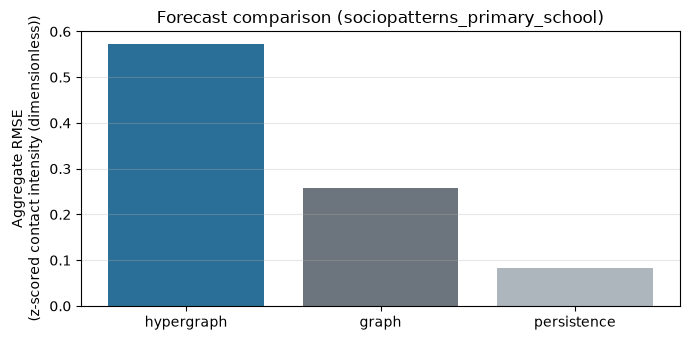

Lowest aggregate RMSE on this run: persistence
Look at h=3: hypergraph RMSE=0.6301 vs persistence RMSE=0.2485 (contact intensity; DATA_SOURCE=sociopatterns_primary_school)


In [9]:
labels = [row["model"] for row in rows]
agg = [row["aggregate_rmse"] for row in rows]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(labels, agg, color=["#2a6f97", "#6c757d", "#adb5bd"])
ax.set_ylabel(f"Aggregate RMSE\n({FEATURE_UNIT})")
ax.set_title(f"Forecast comparison ({DATA_SOURCE})")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

winner = min(rows, key=lambda row: row["aggregate_rmse"])["model"]
worst_h = max(HORIZONS)
hg_worst = next(r for r in rows if r["model"] == "hypergraph")[f"h{worst_h}_rmse"]
persist_worst = next(r for r in rows if r["model"] == "persistence")[
    f"h{worst_h}_rmse"
]
print(f"Lowest aggregate RMSE on this run: {winner}")
print(
    f"Look at h={worst_h}: hypergraph RMSE={hg_worst:.4f} vs "
    f"persistence RMSE={persist_worst:.4f} "
    f"({FEATURE_LABEL}; DATA_SOURCE={DATA_SOURCE})"
)


### Effective-matrix spectrum (hypergraph)

For `koopman="hypergraph"`, networked eigenvalues come from the Kronecker
effective matrix
$I \otimes K_{\mathrm{self}} + \hat{H} \otimes K_{\mathrm{hedge}}$,
not from $K_{\mathrm{self}}$ alone. Call `model.spectrum` with the sequence
incidence. In discrete time, eigenvalues with $|\lambda| > 1$ (outside the
dashed unit circle) indicate an expansive linear step — often visible later as
rising multi-horizon RMSE.


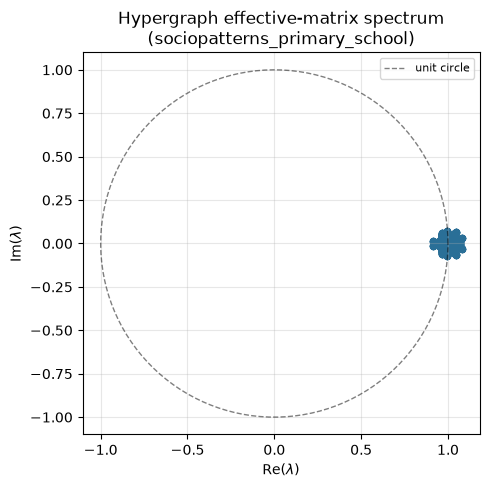

DATA_SOURCE=sociopatterns_primary_school  num eigenvalues=7744  max |λ|=1.0808
Note: max |λ| > 1 (outside the unit circle) — the discrete hypergraph step is expansive on this fit; check whether long-horizon RMSE grows.


In [10]:
spectrum = hg_model.spectrum(
    hyperedge_index=hg_sequence.hyperedge_index,
    num_nodes=hg_sequence.num_nodes,
    hyperedge_weight=hg_sequence.hyperedge_weight,
)
eigs = spectrum.eigenvalues.detach().cpu().numpy()
max_abs = float(np.max(np.abs(eigs)))
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eigs.real, eigs.imag, s=18, alpha=0.8, c="#2a6f97")
theta = np.linspace(0, 2 * np.pi, 256)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=1, alpha=0.5, label="unit circle")
ax.set_aspect("equal")
ax.set_xlabel(r"Re($\lambda$)")
ax.set_ylabel(r"Im($\lambda$)")
ax.set_title(f"Hypergraph effective-matrix spectrum\n({DATA_SOURCE})")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print(
    f"DATA_SOURCE={DATA_SOURCE}  num eigenvalues={eigs.size}  "
    f"max |λ|={max_abs:.4f}"
)
if max_abs > 1.0 + 1e-6:
    print(
        "Note: max |λ| > 1 (outside the unit circle) — the discrete hypergraph "
        "step is expansive on this fit; check whether long-horizon RMSE grows."
    )
else:
    print("Note: all plotted |λ| ≤ 1 on this fit (contractive / marginal).")


## Interpretation

- **What this run measured.** Results above are for `DATA_SOURCE` printed in
  the metric cell. Synthetic paths demonstrate the API and a controlled
  incidence contrast; `sociopatterns_primary_school` supports only a thin
  teaching comparison on the default day-long hourly cache ($T=24$, small
  test slice, static top-$K$ hyperedges) — not week-scale contact forecasting.
- **Encoder/decoder vs operator capacity.** Hidden/latent depth match across
  stacks; the hypergraph path still learns $K_{\mathrm{hedge}}$. A higher
  hypergraph RMSE is therefore not proof that “groups hurt” in general — it can
  reflect static incidence misspecification, short holdout, or an expansive
  fitted spectrum.
- **Static hyperedges.** SocioPatterns teaching incidence aggregates groups
  over the **training** wall-clock window only (`HYPEREDGE_WINDOW`), then holds
  $\hat{H}$ fixed. That avoids holdout leakage into hyperedge counts, but real
  proximity groups rewire every 20 seconds; a static $\hat{H}$ still cannot
  represent that fully. Pairwise edges in the cache remain full-window.
- **Features.** On the SocioPatterns path, intensity is a contact-activity
  proxy, not an epidemic state. Do not read MAE/RMSE as infection-forecast
  skill.
- **Spectrum ↔ horizons.** When `max |λ| > 1`, expect multi-step error to grow
  faster than persistence on smooth series — connect that reading to the
  per-horizon table rather than to the aggregate bar alone.
- **Persistence / degenerate short horizons.** On short, smooth series,
  repeating the last bin can win aggregate RMSE. If persistence $h=1$ or $h=2$
  RMSE is $\approx 0$, consecutive holdout bins are identical: that baseline
  win is a **data property** of the teaching window, not evidence against
  learning. Prefer longer horizons and the non-constant-origin subset printed
  in Results when judging models. Equal consecutive-horizon RMSE for a learned
  model is a sanity flag: use the origin-wise target/prediction deltas in
  Results. On this SocioPatterns holdout those deltas are zero for both
  targets and hypergraph predictions at $h=1$/$h=2$, so the tie is holdout
  stationarity plus a non-changing multi-step forecast — not a metrics bug.


## Takeaways

- Use `koopman="hypergraph"` with `HypergraphEncoder` / `HypergraphDecoder`
  when group incidence is available **and** you specifically want a linear
  latent advance through Zhou-normalized hyperedges — not because hyperedges
  automatically lower RMSE on a short teaching holdout.
- Prefer the pairwise `koopman="graph"` stack when only dyadic topology is
  trustworthy, when hyperedge construction is ambiguous, or when a short
  chronological holdout shows the graph (or persistence) already wins.
- Always include chronological holdout + persistence before claiming skill.
  Gotchas: default SocioPatterns cache is one day ($T=24$) with a tiny test
  slice; static top-$K$ hyperedges from the **train** window only; expansive
  spectra (`|\lambda| > 1`); persistence RMSE $\approx 0$ at short horizons
  when consecutive bins match; and committed figures refresh only for the
  `DATA_SOURCE` of the latest full re-run.
- Hypergraph underperformance on this notebook’s thin window does **not** mean
  group incidence is useless for contact modeling — widen the series or rebuild
  the cache with more bins before drawing that conclusion.
- SocioPatterns assets are CC-BY-NC-SA: fetch + SHA256 only; cite Gemmetto /
  Stehlé and acknowledge SocioPatterns. Cite Zhou et al. (2006) for the
  $\hat{H}$ normalization used by the operator.


## Further reading

- API: `koopman_graph.nn.HypergraphEncoder`, `HypergraphDecoder`,
  `GraphKoopmanModel(..., koopman="hypergraph")`, `model.spectrum(...)`
- Dataset card: Sphinx page [`docs/source/data.rst`](../docs/source/data.rst)
  (section **SocioPatterns primary-school contacts**); rendered docs page
  `data.html` under the package documentation site when built
- Related notebooks: [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb),
  [`06_epidemic_ring.ipynb`](06_epidemic_ring.ipynb),
  [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb)
- Citations (`paper.bib`): `Zhou2006Hypergraphs`, `Wang2025PhyHSL`,
  `Mao2025HyperPINN`, `Delabays2025Hypergraph`, `Gemmetto2014`, `Stehle2011`
